# Biomarker Discovery from MOFA + Linear SVM

Objective:
- identify the MOFA factors most consistently important for subtype classification
- map those factors back to the original omics features
- derive candidate biomarkers across mRNA, miRNA, and DNA methylation


In [1]:
import pandas as pd
import numpy as np
import mofax as mfx
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)

In [2]:
mrna_data_vsn_fs = pd.read_csv("../../data/feature_selection/selected_features_mrna_data_vsn.csv", index_col=0)
mirna_data_vsn_fs = pd.read_csv("../../data/feature_selection/selected_features_mirna_data_vsn.csv", index_col=0)
meth_data_fs = pd.read_csv("../../data/feature_selection/selected_features_meth_data.csv", index_col=0)

In [3]:
clinical_data = pd.read_csv("../../data/cleaned_data/clinical_cleaned.csv", index_col=0)
y = clinical_data["tumor_subtype"].map({"other_subtype": 1, "ductal_type": 0})

In [4]:
def load_mofa_factors(model_path, clinical_index):
    model = mfx.mofa_model(model_path)
    factors = model.get_factors(df=True)
    factors = factors.loc[clinical_index]
    return model, factors

In [5]:
model_path = "../../data/latent/mofa_trained_vsn_fs.hdf5"
mofa_model, X = load_mofa_factors(model_path, clinical_data.index)

In [6]:
print(X.shape)
display(X.head())

(176, 10)


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
patient_id,,,,,,,,,,
TCGA-2J-AAB1,1.846789,1.404765,-0.073263,0.364550,-0.275643,-0.062900,0.066504,3.088176,-0.041426,0.142506
TCGA-2J-AAB4,0.413031,0.158443,0.482249,-1.621558,0.201344,0.099848,-0.214202,0.681693,0.557081,0.398764
TCGA-2J-AAB6,1.488815,1.811948,-3.019068,-1.567511,-0.968232,-1.909873,0.199540,1.980096,0.410115,-0.368314
TCGA-2J-AAB8,1.705274,-1.985239,0.602638,0.902741,0.203677,-1.370834,-0.178664,1.429240,0.033482,-0.473454
TCGA-2J-AAB9,-1.056744,-1.295832,-0.081001,-2.247182,0.089500,0.945770,-0.135600,2.755386,-0.182717,0.067042


In [7]:
param_grid = {
    "svm__C": [0.01, 0.1, 1, 10, 100]
}

scoring = {
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "pr_auc_score": make_scorer(average_precision_score, response_method="decision_function"),
}


In [8]:
outer_cv_splits = 5
inner_cv_splits = 5
seeds = list(range(30))

coefficient_rows = []
performance_rows = []

for seed in seeds:
    outer_cv = StratifiedKFold(n_splits=outer_cv_splits, shuffle=True, random_state=seed)
    
    pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(class_weight="balanced", dual="auto", random_state=seed, max_iter=10000))
    ])
    
    for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        inner_cv = StratifiedKFold(n_splits=inner_cv_splits, shuffle=True, random_state=seed)

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring=scoring,
            refit="pr_auc_score",
            cv=inner_cv,
            n_jobs=-1,
            return_train_score=False
        )

        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

        y_pred = best_model.predict(X_test)
        y_score = best_model.decision_function(X_test)

        performance_rows.append({
            "seed": seed,
            "fold": fold_id,
            "best_params": str(grid_search.best_params_),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "pr_auc": average_precision_score(y_test, y_score),
        })

        coefs = best_model.named_steps["svm"].coef_[0]

        for factor, coef in zip(X.columns, coefs):
            coefficient_rows.append({
                "seed": seed,
                "fold": fold_id,
                "factor": factor,
                "coefficient": coef,
                "abs_coefficient": abs(coef),
                "direction": "other_subtype" if coef > 0 else "ductal_type" if coef < 0 else "neutral"
            })


In [9]:
coefficients_df = pd.DataFrame(coefficient_rows)
performance_df = pd.DataFrame(performance_rows)

In [10]:
display(coefficients_df.head())
display(performance_df.head())

,seed,fold,factor,coefficient,abs_coefficient,direction
0,0,1,Factor1,-0.182853,0.182853,ductal_type
1,0,1,Factor2,0.116193,0.116193,other_subtype
2,0,1,Factor3,-0.084974,0.084974,ductal_type
3,0,1,Factor4,0.150754,0.150754,other_subtype
4,0,1,Factor5,0.046272,0.046272,other_subtype


,seed,fold,best_params,balanced_accuracy,precision,recall,f1,pr_auc
0,0,1,{'svm__C': 0.01},0.800000,0.666667,0.666667,0.666667,0.600694
1,0,2,{'svm__C': 0.01},0.781609,0.571429,0.666667,0.615385,0.597050
2,0,3,{'svm__C': 1},0.643678,0.266667,0.666667,0.380952,0.553558
3,0,4,{'svm__C': 1},0.479885,0.142857,0.166667,0.153846,0.329166
4,0,5,{'svm__C': 0.1},0.800000,0.400000,0.800000,0.533333,0.774242


In [17]:
factor_summary = (
    coefficients_df
    .groupby("factor", as_index=False)
    .agg(
        mean_coefficient=("coefficient", "mean"),
        mean_abs_coefficient=("abs_coefficient", "mean"),
        median_abs_coefficient=("abs_coefficient", "median"),
        std_abs_coefficient=("abs_coefficient", "std"),
        times_positive=("coefficient", lambda s: int((s > 0).sum())),
        times_negative=("coefficient", lambda s: int((s < 0).sum())),
        times_zero=("coefficient", lambda s: int((s == 0).sum())),
        n_models=("coefficient", "size")
    )
)

factor_summary['stability'] = (factor_summary[["times_positive", "times_negative"]].max(axis=1) / factor_summary["n_models"])

factor_summary['dominant_direction'] = np.where(
    factor_summary['times_positive'] > factor_summary['times_negative'], "other_subtype",
    np.where(factor_summary['times_negative'] > factor_summary['times_positive'], "ductal_type", "neutral")
)

factor_summary = factor_summary.sort_values(['mean_abs_coefficient', 'stability'], ascending=[False, False]).reset_index(drop=True)

In [18]:
display(factor_summary)

,factor,mean_coefficient,mean_abs_coefficient,median_abs_coefficient,std_abs_coefficient,times_positive,times_negative,times_zero,n_models,stability,dominant_direction
0,Factor1,-0.542095,0.542095,0.583554,0.299238,0,150,0,150,1.000000,ductal_type
1,Factor7,-0.258669,0.265585,0.231862,0.245296,7,143,0,150,0.953333,ductal_type
2,Factor2,0.252211,0.252211,0.230763,0.150280,150,0,0,150,1.000000,other_subtype
3,Factor5,0.236217,0.250197,0.186213,0.209643,143,7,0,150,0.953333,other_subtype
4,Factor8,0.205161,0.205161,0.199779,0.059007,150,0,0,150,1.000000,other_subtype
5,Factor4,0.194166,0.194166,0.172921,0.094982,150,0,0,150,1.000000,other_subtype
6,Factor9,0.138533,0.138883,0.112158,0.105407,148,2,0,150,0.986667,other_subtype
7,Factor6,-0.130504,0.133489,0.118463,0.107127,12,138,0,150,0.920000,ductal_type
8,Factor10,0.068991,0.084146,0.057539,0.072226,118,32,0,150,0.786667,other_subtype
9,Factor3,-0.052010,0.082543,0.080173,0.034479,21,129,0,150,0.860000,ductal_type


In [34]:
top_k = 5
min_stability = 0.9

robust_factors = factor_summary.loc[factor_summary["stability"] >= min_stability].head(top_k).copy()

top_factors = robust_factors["factor"].tolist()

In [35]:
robust_factors

,factor,mean_coefficient,mean_abs_coefficient,median_abs_coefficient,std_abs_coefficient,times_positive,times_negative,times_zero,n_models,stability,dominant_direction
0,Factor1,-0.542095,0.542095,0.583554,0.299238,0,150,0,150,1.000000,ductal_type
1,Factor7,-0.258669,0.265585,0.231862,0.245296,7,143,0,150,0.953333,ductal_type
2,Factor2,0.252211,0.252211,0.230763,0.150280,150,0,0,150,1.000000,other_subtype
3,Factor5,0.236217,0.250197,0.186213,0.209643,143,7,0,150,0.953333,other_subtype
4,Factor8,0.205161,0.205161,0.199779,0.059007,150,0,0,150,1.000000,other_subtype


In [20]:
display(top_factors)

['Factor1', 'Factor7', 'Factor2', 'Factor5', 'Factor8']

Extract MOFA weights

In [21]:
weights_df = mofa_model.get_weights(df=True)

display(weights_df.head())

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
ENSG00000000003,0.005497,-0.002377,-0.002999,-0.003571,-3.503687e-06,0.002044,4.274295e-07,-9.660314e-08,-1.100453e-07,0.011566
ENSG00000000460,0.002917,-0.000004,-0.002635,0.002773,-4.711943e-07,-0.003890,1.053027e-06,9.209595e-08,-6.746733e-07,0.015695
ENSG00000000938,0.000016,-0.011756,0.004317,0.001013,-2.583346e-05,-0.003754,2.295939e-06,-2.380894e-07,1.243465e-06,0.014679
ENSG00000000971,0.001768,-0.008830,0.006107,-0.003898,-1.279115e-04,-0.006179,-3.249432e-05,1.696427e-07,-9.082739e-07,0.025126
ENSG00000001167,0.002268,-0.000002,0.000849,0.002648,8.389202e-06,-0.003648,-3.223921e-07,8.253413e-09,-6.551385e-07,0.016557


In [ ]:
weights_reset = weights_df.reset_index()
weights_long = (
    weights_df
    .reset_index()
    .melt(
        id_vars=["index"],
        var_name="factor",
        value_name="weight"
    )
    .rename(columns={"index": "feature"})
)

weights_long["abs_weight"] = weights_long["weight"].abs()

display(weights_long.head())


,feature,factor,weight,abs_weight
0,ENSG00000000003,Factor1,0.005497,0.005497
1,ENSG00000000460,Factor1,0.002917,0.002917
2,ENSG00000000938,Factor1,0.000016,0.000016
3,ENSG00000000971,Factor1,0.001768,0.001768
4,ENSG00000001167,Factor1,0.002268,0.002268


In [25]:
mrna_features = set(mrna_data_vsn_fs.columns)
mirna_features = set(mirna_data_vsn_fs.columns)
meth_features = set(meth_data_fs.columns)

In [26]:
def assign_view(feature):
    if feature in mrna_features:
        return "mRNA"
    elif feature in mirna_features:
        return "miRNA"
    elif feature in meth_features:
        return "Methylation"
    else:
        return "Unknown"

In [27]:
weights_long['view'] = weights_long['feature'].apply(assign_view)

In [28]:
display(weights_long)

,feature,factor,weight,abs_weight,view
0,ENSG00000000003,Factor1,0.005497,0.005497,mRNA
1,ENSG00000000460,Factor1,0.002917,0.002917,mRNA
2,ENSG00000000938,Factor1,0.000016,0.000016,mRNA
3,ENSG00000000971,Factor1,0.001768,0.001768,mRNA
4,ENSG00000001167,Factor1,0.002268,0.002268,mRNA
...,...,...,...,...,...
709735,cg18851100,Factor10,-0.023025,0.023025,Methylation
709736,cg13213810,Factor10,-0.046587,0.046587,Methylation
709737,cg12502079,Factor10,-0.029857,0.029857,Methylation
709738,cg06422471,Factor10,-0.052069,0.052069,Methylation


Cruzar direção de SVM com pesos do MOFA

Agora vais combinar:

direção do fator no SVM
sinal do peso da feature no MOFA
Regra:

fator other_subtype + peso positivo -> feature apoia other_subtype

fator other_subtype + peso negativo -> feature apoia ductal_type

fator ductal_type + peso positivo -> feature apoia ductal_type

fator ductal_type + peso negativo -> feature apoia other_subtype

In [29]:
top_features_per_sign = 15

candidate_rows = []

for _, factor_row in factor_summary.iterrows():
    factor = factor_row["factor"]
    factor_direction = factor_row["dominant_direction"]

    subset = weights_long.loc[weights_long["factor"] == factor].copy()

    for view_name, view_df in subset.groupby('view'):
        top_pos = view_df.sort_values("weight", ascending=False).head(top_features_per_sign)
        top_neg = view_df.sort_values("weight").head(top_features_per_sign)

        selected = pd.concat([top_pos, top_neg], axis = 0).drop_duplicates()

        for _, row in selected.iterrows():
            if factor_direction == "other_subtype":
                feature_direction = "other_subtype" if row["weight"] > 0 else "ductal_type"
            elif factor_direction == "ductal_type":
                feature_direction = "ductal_type" if row["weight"] > 0 else "other_subtype"
            else:
                feature_direction = "neutral"

            candidate_rows.append({
                "factor": factor,
                "factor_direction": factor_direction,
                "factor_mean_abs_coefficient": factor_row["mean_abs_coefficient"],
                "factor_stability": factor_row["stability"],
                "view": row["view"],
                "feature": row["feature"],
                "weight": row["weight"],
                "abs_weight": row["abs_weight"],
                "feature_direction": feature_direction
            })

candidate_biomarkers = (pd.DataFrame(candidate_rows).sort_values(["factor_mean_abs_coefficient", "factor", "view", "abs_weight"], ascending=[False, True, True,False]).reset_index(drop=True))

In [30]:
display(candidate_biomarkers.head(20))

,factor,factor_direction,factor_mean_abs_coefficient,factor_stability,view,feature,weight,abs_weight,feature_direction
0,Factor1,ductal_type,0.542095,1.0,Methylation,cg10536999,-0.561907,0.561907,other_subtype
1,Factor1,ductal_type,0.542095,1.0,Methylation,cg12563935,0.535716,0.535716,ductal_type
2,Factor1,ductal_type,0.542095,1.0,Methylation,cg07700514,0.535569,0.535569,ductal_type
3,Factor1,ductal_type,0.542095,1.0,Methylation,cg04904331,0.534368,0.534368,ductal_type
4,Factor1,ductal_type,0.542095,1.0,Methylation,cg16389901,-0.529511,0.529511,other_subtype
5,Factor1,ductal_type,0.542095,1.0,Methylation,cg20151476,-0.524580,0.524580,other_subtype
6,Factor1,ductal_type,0.542095,1.0,Methylation,cg01893212,0.519085,0.519085,ductal_type
7,Factor1,ductal_type,0.542095,1.0,Methylation,cg20434926,-0.510976,0.510976,other_subtype
8,Factor1,ductal_type,0.542095,1.0,Methylation,cg02467990,0.509585,0.509585,ductal_type
9,Factor1,ductal_type,0.542095,1.0,Methylation,cg00582971,0.505884,0.505884,ductal_type


In [31]:
candidate_biomarkers["rank_within_factor_view"] = (
    candidate_biomarkers
    .groupby(["factor", "view"])["abs_weight"]
    .rank(method="first", ascending=False)
)

final_candidate_biomarkers = candidate_biomarkers.sort_values(
    ["factor_mean_abs_coefficient", "factor", "view", "rank_within_factor_view"],
    ascending=[False, True, True, True]
).reset_index(drop=True)

In [39]:
display(final_candidate_biomarkers.head(30))

,factor,factor_direction,factor_mean_abs_coefficient,factor_stability,view,feature,weight,abs_weight,feature_direction,rank_within_factor_view
0,Factor1,ductal_type,0.542095,1.0,Methylation,cg10536999,-0.561907,0.561907,other_subtype,1.0
1,Factor1,ductal_type,0.542095,1.0,Methylation,cg12563935,0.535716,0.535716,ductal_type,2.0
2,Factor1,ductal_type,0.542095,1.0,Methylation,cg07700514,0.535569,0.535569,ductal_type,3.0
3,Factor1,ductal_type,0.542095,1.0,Methylation,cg04904331,0.534368,0.534368,ductal_type,4.0
4,Factor1,ductal_type,0.542095,1.0,Methylation,cg16389901,-0.529511,0.529511,other_subtype,5.0
5,Factor1,ductal_type,0.542095,1.0,Methylation,cg20151476,-0.524580,0.524580,other_subtype,6.0
6,Factor1,ductal_type,0.542095,1.0,Methylation,cg01893212,0.519085,0.519085,ductal_type,7.0
7,Factor1,ductal_type,0.542095,1.0,Methylation,cg20434926,-0.510976,0.510976,other_subtype,8.0
8,Factor1,ductal_type,0.542095,1.0,Methylation,cg02467990,0.509585,0.509585,ductal_type,9.0
9,Factor1,ductal_type,0.542095,1.0,Methylation,cg00582971,0.505884,0.505884,ductal_type,10.0


In [49]:
view_contribution_summary = (
    candidate_biomarkers
    .groupby(["factor", "view"], as_index=False)
    .agg(
        n_features=("feature", "count"),
        mean_abs_weight=("abs_weight", "mean"),
        median_abs_weight=("abs_weight", "median"),
        max_abs_weight=("abs_weight", "max"),
    )
    .sort_values(["factor", "max_abs_weight"], ascending=[True, False])
)

display(view_contribution_summary)


,factor,view,n_features,mean_abs_weight,median_abs_weight,max_abs_weight
0,Factor1,Methylation,30,0.501614,0.497896,0.561907
1,Factor1,mRNA,30,0.213082,0.210826,0.272388
2,Factor1,miRNA,30,0.068812,0.066170,0.141780
3,Factor10,Methylation,30,0.244278,0.239895,0.272434
4,Factor10,mRNA,30,0.028515,0.033329,0.040755
5,Factor10,miRNA,30,0.008468,0.008635,0.013215
6,Factor2,Methylation,30,0.555414,0.541631,0.639341
7,Factor2,mRNA,30,0.143691,0.151468,0.210607
8,Factor2,miRNA,30,0.005784,0.005103,0.014268
9,Factor3,Methylation,30,0.589579,0.634865,0.785385


In [50]:
dominant_view_per_factor = (
    view_contribution_summary
    .sort_values(["factor", "max_abs_weight"], ascending=[True, False])
    .groupby("factor", as_index=False)
    .first()
)

display(dominant_view_per_factor)


,factor,view,n_features,mean_abs_weight,median_abs_weight,max_abs_weight
0,Factor1,Methylation,30,0.501614,0.497896,0.561907
1,Factor10,Methylation,30,0.244278,0.239895,0.272434
2,Factor2,Methylation,30,0.555414,0.541631,0.639341
3,Factor3,Methylation,30,0.589579,0.634865,0.785385
4,Factor4,Methylation,30,0.523548,0.544141,0.618734
5,Factor5,Methylation,30,0.786030,0.795417,0.884109
6,Factor6,Methylation,30,0.884411,0.896564,1.145802
7,Factor7,Methylation,30,1.308693,1.247859,1.841301
8,Factor8,Methylation,30,0.672619,0.708458,0.805628
9,Factor9,Methylation,30,0.689617,0.717711,0.881133


conclusão: Aparece Methylation em todos os fatores, indica evidência quantitativa clara de dominância dessa omics.

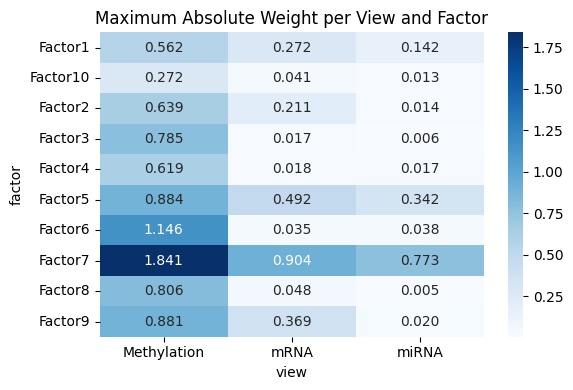

In [52]:
heatmap_df = view_contribution_summary.pivot(
    index="factor",
    columns="view",
    values="max_abs_weight"
)

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_df, annot=True, cmap="Blues", fmt=".3f")
plt.title("Maximum Absolute Weight per View and Factor")
plt.tight_layout()
plt.show()
